In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("VahaanDataset_before_cleaning.csv")

In [3]:
df.head()

,Unnamed: 0,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5
1,1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4
2,2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,0,2,1
3,3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3
4,4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2


In [4]:
df.isnull().sum()

Unnamed: 0             0
Registration_Number    0
Registration_Date      0
Registration_Year      0
State                  0
RTO_Office             0
Vehicle_Category       0
Vehicle_Sub_Type       0
Manufacturer_Brand     0
Fuel_Type              0
Emission_Norm          0
Engine_CC              0
Seating_Capacity       0
Vehicle_Age_Years      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop(columns = ["Unnamed: 0"])

In [7]:
print(df.columns)

Index(['Registration_Number', 'Registration_Date', 'Registration_Year',
       'State', 'RTO_Office', 'Vehicle_Category', 'Vehicle_Sub_Type',
       'Manufacturer_Brand', 'Fuel_Type', 'Emission_Norm', 'Engine_CC',
       'Seating_Capacity', 'Vehicle_Age_Years'],
      dtype='object')


In [8]:
type(df)

pandas.core.frame.DataFrame

In [9]:
summary_df = pd.DataFrame({"Unique_Data": df.nunique(), "Null_Value": df.isnull().sum(), "dtypes": df.dtypes})

In [10]:
summary_df

,Unique_Data,Null_Value,dtypes
Registration_Number,3700,0,object
Registration_Date,1861,0,object
Registration_Year,7,0,int64
State,12,0,object
RTO_Office,60,0,object
Vehicle_Category,6,0,object
Vehicle_Sub_Type,20,0,object
Manufacturer_Brand,32,0,object
Fuel_Type,5,0,object
Emission_Norm,3,0,object


In [11]:
# Metrics relevant to the regn. year, vehicle type, fuel type and emission norm.
print("\nTop 12 states by registrations:")
print(df['State'].value_counts().head(12))
print("\nVehicle category values:")
print(df['Vehicle_Category'].value_counts())

print("\nFuel type values:")
print(df['Fuel_Type'].value_counts())

print("\nDifferent emission norms:")
print(df['Emission_Norm'].value_counts())

print("\nRegistration Year Distribution:")
print(df['Registration_Year'].value_counts().sort_index())


Top 12 states by registrations:
State
Karnataka         975
Kerala            269
Madhya Pradesh    262
Punjab            260
Tamil Nadu        260
Delhi             250
Rajasthan         245
Gujarat           242
Uttar Pradesh     240
West Bengal       238
Telangana         234
Maharashtra       225
Name: count, dtype: int64

Vehicle category values:
Vehicle_Category
2W     1648
4W     1160
3W      281
LCV     269
HCV     228
OTH     114
Name: count, dtype: int64

Fuel type values:
Fuel_Type
Petrol    1389
Diesel     929
EV         748
CNG        480
Hybrid     154
Name: count, dtype: int64

Different emission norms:
Emission_Norm
BS6    3087
BS4     606
BS3       7
Name: count, dtype: int64

Registration Year Distribution:
Registration_Year
2018    206
2019    307
2020    443
2021    595
2022    710
2023    853
2024    586
Name: count, dtype: int64


In [12]:
oem_fuel = pd.crosstab(df['Manufacturer_Brand'], df['Fuel_Type'])
print("OEMs by fuel type:")
print(oem_fuel.head)

OEMs by fuel type:
<bound method NDFrame.head of Fuel_Type           CNG  Diesel  EV  Hybrid  Petrol
Manufacturer_Brand                                 
Ashok Leyland        18      63   9       0       0
Ather                12       0  53       7      89
Atul Auto            15       8  18       0       5
Bajaj                42      11  54       7      75
BharatBenz            3      28   1       0       0
Eicher                9      71   9       0       0
Escorts               0      20   0       0       4
Force Motors         11      38   5       0       0
Hero                 15       0  52       4      99
Honda                24      37  69      11     149
Hyundai              11      41  17       9      42
John Deere            0      19   0       0       4
KTM                  18       0  59       8      86
Kia                   9      30  12       5      54
Kinetic Green        20      16   8       0       2
MAN                   3      39   3       0       0
MG             

In [13]:
# Data Cleaning / Anamolies

In [14]:
df.head()

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,0,2,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2


In [15]:
# RTO code distribution.
df['RTO_State_Code'] = df['RTO_Office'].str.extract(r'\(([A-Z]{2})-\d+\)')
print("\nRTO state code distribution:")
print(df['RTO_State_Code'].value_counts())


RTO state code distribution:
RTO_State_Code
KA    355
KL    338
MP    322
TN    319
DL    312
RJ    302
WB    296
GJ    289
UP    287
TS    286
MH    273
PB    256
CH     65
Name: count, dtype: int64


In [16]:
df[['RTO_State_Code','RTO_Office']]

,RTO_State_Code,RTO_Office
0,MP,Bhopal (MP-04)
1,KA,Belgaum (KA-22)
2,DL,Delhi South (DL-09)
3,RJ,Kota (RJ-20)
4,GJ,Ahmedabad (GJ-01)
...,...,...
3695,RJ,Kota (RJ-20)
3696,PB,Patiala (PB-11)
3697,KA,Hubli (KA-25)
3698,GJ,Surat (GJ-05)


In [17]:
# RTO code mismatch.
state_map = {
    'Karnataka': 'KA', 'Kerala': 'KL', 'Madhya Pradesh': 'MP', 'Punjab': 'PB',
    'Tamil Nadu': 'TN', 'Delhi': 'DL', 'Rajasthan': 'RJ', 'Gujarat': 'GJ',
    'Uttar Pradesh': 'UP', 'West Bengal': 'WB', 'Maharashtra': 'MH', 'Haryana': 'HR'
}
df['Expected_State_Code'] = df['State'].map(state_map)
state_rto_mismatch = df[df['Expected_State_Code'] != df['RTO_State_Code']]
print(f"\nState vs RTO code mismatches: {len(state_rto_mismatch)} out of {len(df)}.")
print(state_rto_mismatch[['State', 'RTO_Office', 'RTO_State_Code']].head(10))


State vs RTO code mismatches: 909 out of 3700.
        State                  RTO_Office RTO_State_Code
2   Karnataka         Delhi South (DL-09)             DL
3   Karnataka                Kota (RJ-20)             RJ
4   Karnataka           Ahmedabad (GJ-01)             GJ
5   Karnataka  Thiruvananthapuram (KL-01)             KL
6   Karnataka            Durgapur (WB-40)             WB
7   Karnataka            Ludhiana (PB-10)             PB
8   Karnataka             Gwalior (MP-07)             MP
9   Karnataka            Amritsar (PB-02)             PB
10  Karnataka              Kollam (KL-02)             KL
11  Karnataka      Mumbai Central (MH-01)             MH


In [18]:
# Fuel Type mismatch.
print("\nFuel type invalid:")
print("For Ola Electric:")
print(df[df['Manufacturer_Brand'] == 'Ola Electric']['Fuel_Type'].value_counts())


Fuel type invalid:
For Ola Electric:
Fuel_Type
Petrol    85
EV        51
CNG       15
Hybrid    12
Name: count, dtype: int64


In [19]:
# Emission norms distribution.
print("\nEmission norms by registration year:")
print(pd.crosstab(df['Registration_Year'], df['Emission_Norm']))


Emission norms by registration year:
Emission_Norm      BS3  BS4  BS6
Registration_Year               
2018                 7  199    0
2019                 0  282   25
2020                 0   68  375
2021                 0   29  566
2022                 0   16  694
2023                 0   12  841
2024                 0    0  586


In [20]:
# Incorrect Emission Norm

print("\nInvalid emission norm:")

df['Registration_Date_dt'] = pd.to_datetime(
    df['Registration_Date'],
    format='%d-%m-%Y'
)

print("BS4 post Apr 2021:",len(df[(df['Emission_Norm'] == 'BS4') & (df['Registration_Date_dt'] > '2021-04-01') ] ))


Invalid emission norm:
BS4 post Apr 2021: 53


In [21]:
# Drop columns created for analysis. Let cleaning handle that.
df = df.drop(columns=['RTO_State_Code', 'Expected_State_Code', 'Registration_Date_dt'])

In [22]:
df.head()

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,0,2,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2


In [23]:
# Data cleaning for further analysis.

# 1. Drop any duplicates.
df = df.drop_duplicates()

In [24]:
df.head()

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,0,2,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2


In [25]:
# 2. Temporal data

df['Registration_Date'] = pd.to_datetime(
    df['Registration_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

df['Registration_Month'] = df['Registration_Date'].dt.month
df['Registration_Day'] = df['Registration_Date'].dt.day
df['Registration_DayOfWeek'] = df['Registration_Date'].dt.day_name()

In [26]:
df.head()

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years,Registration_Month,Registration_Day,Registration_DayOfWeek
0,REG100001,2019-12-13,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5,12,13,Friday
1,REG100002,2020-01-14,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4,1,14,Tuesday
2,REG100003,2023-03-23,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,0,2,1,3,23,Thursday
3,REG100004,2021-06-26,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3,6,26,Saturday
4,REG100005,2022-11-13,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2,11,13,Sunday


In [27]:
df['RTO_State_Prefix'] = (
    df['RTO_Office']
    .str.extract(r'\(([A-Z]{2})-\d+\)', expand=False)
)

In [28]:
df[['RTO_Office', 'RTO_State_Prefix']].head()

,RTO_Office,RTO_State_Prefix
0,Bhopal (MP-04),MP
1,Belgaum (KA-22),KA
2,Delhi South (DL-09),DL
3,Kota (RJ-20),RJ
4,Ahmedabad (GJ-01),GJ


In [29]:
# 4. Update the state code.
state_code_to_name = {
    'KA': 'Karnataka', 'KL': 'Kerala', 'MP': 'Madhya Pradesh', 'PB': 'Punjab',
    'TN': 'Tamil Nadu', 'DL': 'Delhi', 'RJ': 'Rajasthan', 'GJ': 'Gujarat',
    'UP': 'Uttar Pradesh', 'WB': 'West Bengal', 'TS': 'Telangana', 'MH': 'Maharashtra',
    'CH': 'Chandigarh', 'HR': 'Haryana'
}

df['State_Clean'] = df['RTO_State_Prefix'].map(state_code_to_name).fillna(df['State'])
df['State_Mismatch_Flag'] = (df['State'] != df['State_Clean']).astype(int)

In [30]:
# 5. Update the fuel type for EVs.
pure_ev_brands = ['Ola Electric', 'Ather']
df['Fuel_Type_Clean'] = df['Fuel_Type']
df.loc[df['Manufacturer_Brand'].isin(pure_ev_brands), 'Fuel_Type_Clean'] = 'EV'
df.loc[df['Fuel_Type_Clean'] == 'EV', 'Engine_CC'] = 0

In [31]:
df.head()

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years,Registration_Month,Registration_Day,Registration_DayOfWeek,RTO_State_Prefix,State_Clean,State_Mismatch_Flag,Fuel_Type_Clean
0,REG100001,2019-12-13,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5,12,13,Friday,MP,Madhya Pradesh,0,Petrol
1,REG100002,2020-01-14,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4,1,14,Tuesday,KA,Karnataka,0,Petrol
2,REG100003,2023-03-23,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,0,2,1,3,23,Thursday,DL,Delhi,1,EV
3,REG100004,2021-06-26,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3,6,26,Saturday,RJ,Rajasthan,1,Petrol
4,REG100005,2022-11-13,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2,11,13,Sunday,GJ,Gujarat,1,Petrol


In [32]:
print("\nCleaned Dataset Shape:",
      df.shape)

print("\nColumns:",
      [col for col in df.columns])


Cleaned Dataset Shape: (3700, 20)

Columns: ['Registration_Number', 'Registration_Date', 'Registration_Year', 'State', 'RTO_Office', 'Vehicle_Category', 'Vehicle_Sub_Type', 'Manufacturer_Brand', 'Fuel_Type', 'Emission_Norm', 'Engine_CC', 'Seating_Capacity', 'Vehicle_Age_Years', 'Registration_Month', 'Registration_Day', 'Registration_DayOfWeek', 'RTO_State_Prefix', 'State_Clean', 'State_Mismatch_Flag', 'Fuel_Type_Clean']


In [33]:
type(df)

pandas.core.frame.DataFrame

In [34]:
# Check the readiness of dataset.
target_cols = ['Emission_Norm', 'Vehicle_Category', 'Registration_Year', 'Fuel_Type', 'Fuel_Type_Clean']

print(df[target_cols].info())

print("\nNull count:")
print(df[target_cols].isnull().sum())

print("\nUnique values:")
for col in target_cols:
    print(f"\nColumn:")
    print(df[col].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3700 entries, 0 to 3699
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Emission_Norm      3700 non-null   object
 1   Vehicle_Category   3700 non-null   object
 2   Registration_Year  3700 non-null   int64 
 3   Fuel_Type          3700 non-null   object
 4   Fuel_Type_Clean    3700 non-null   object
dtypes: int64(1), object(4)
memory usage: 144.7+ KB
None

Null count:
Emission_Norm        0
Vehicle_Category     0
Registration_Year    0
Fuel_Type            0
Fuel_Type_Clean      0
dtype: int64

Unique values:

Column:
Emission_Norm
BS6    3087
BS4     606
BS3       7
Name: count, dtype: int64

Column:
Vehicle_Category
2W     1648
4W     1160
3W      281
LCV     269
HCV     228
OTH     114
Name: count, dtype: int64

Column:
Registration_Year
2023    853
2022    710
2021    595
2024    586
2020    443
2019    307
2018    206
Name: count, dtype: int64

Colu

In [35]:
# Finalize the top 12 states.
top_12_states = df['State_Clean'].value_counts().head(12).index.tolist()
df_top12 = df[df['State_Clean'].isin(top_12_states)]
fuel_by_state = pd.crosstab(df_top12['State_Clean'], df_top12['Fuel_Type_Clean'])
fuel_by_state['Total'] = fuel_by_state.sum(axis=1)

print("\nFuel type distribution across 12 states:")
print(fuel_by_state.sort_values(by='Total', ascending=False))
print(f"\nNote: The 12 selective states dataset covers about {len(df_top12)/len(df)*100:.0f}% of the original dataset.")


Fuel type distribution across 12 states:
Fuel_Type_Clean  CNG  Diesel   EV  Hybrid  Petrol  Total
State_Clean                                             
Karnataka         32     103  107       7     106    355
Kerala            49     100   77       9     103    338
Madhya Pradesh    50      78   79      14     101    322
Tamil Nadu        43      77   89      12      98    319
Delhi             39      60   81      11     121    312
Rajasthan         38      76   78      15      95    302
West Bengal       26      62   77      12     119    296
Gujarat           43      67   80      10      89    289
Uttar Pradesh     27      70   76      11     103    287
Telangana         33      79   63      15      96    286
Maharashtra       35      69   81       7      81    273
Punjab            31      74   64       9      78    256

Note: The 12 selective states dataset covers about 98% of the original dataset.


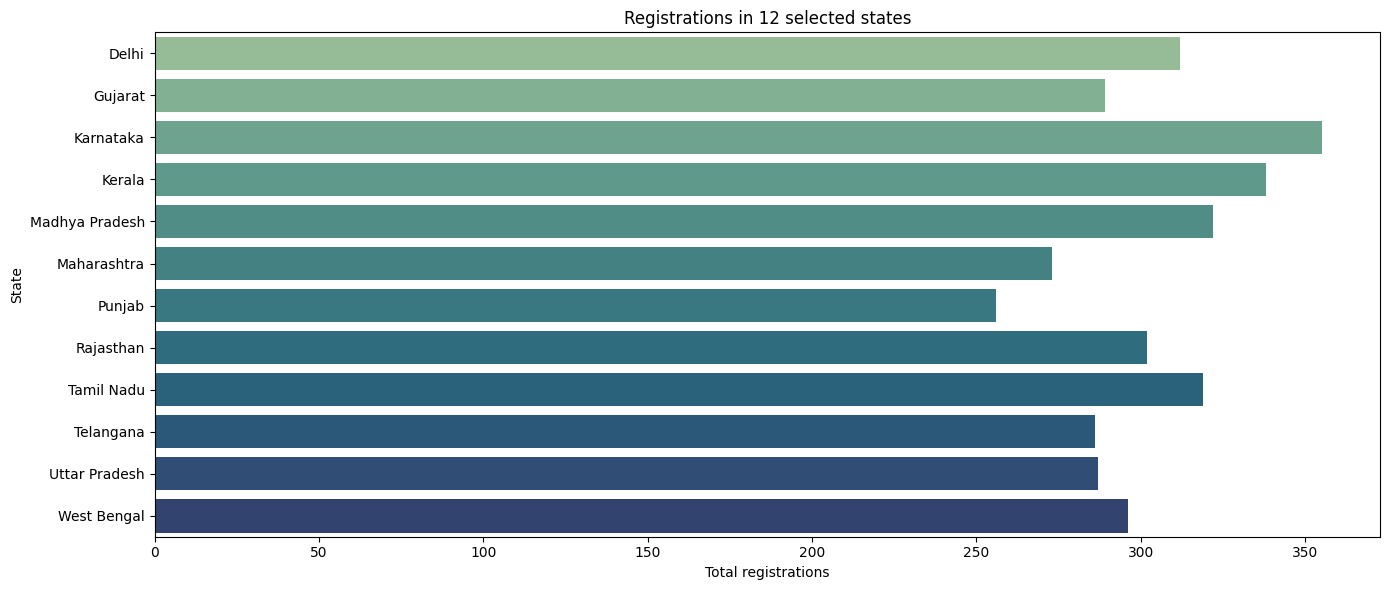

In [36]:
plt.figure(figsize=(14, 6))

sns.barplot(
    y=fuel_by_state.index,
    x=fuel_by_state['Total'],
    palette='crest',
    hue=fuel_by_state.index,
    legend=False
)

plt.title('Registrations in 12 selected states')
plt.xlabel('Total registrations')
plt.ylabel('State')
plt.tight_layout()
plt.show()

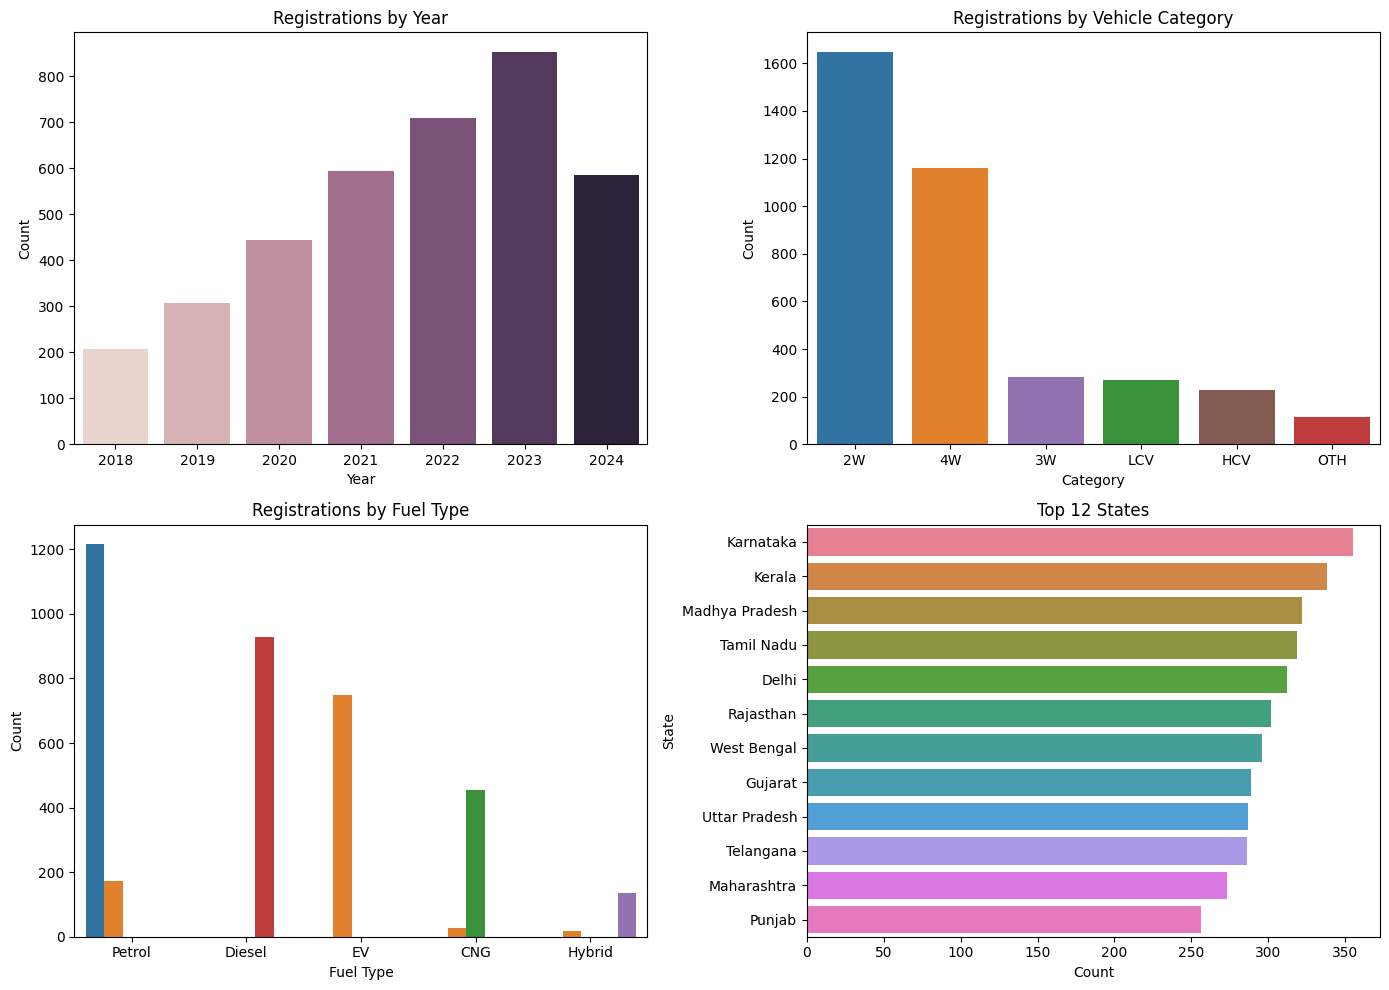

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Registrations by Year
year_counts = df['Registration_Year'].value_counts().sort_index()

sns.barplot(
    x=year_counts.index,
    y=year_counts.values,
    hue=year_counts.index,
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Registrations by Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Count")


# 2. Registrations by Vehicle Category
sns.countplot(
    data=df,
    x='Vehicle_Category',
    order=df['Vehicle_Category'].value_counts().index,
    hue='Vehicle_Category',
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Registrations by Vehicle Category")
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Count")


# 3. Registrations by Fuel Type
sns.countplot(
    data=df,
    x='Fuel_Type',
    order=df['Fuel_Type'].value_counts().index,
    hue='Fuel_Type_Clean',
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Registrations by Fuel Type")
axes[1, 0].set_xlabel("Fuel Type")
axes[1, 0].set_ylabel("Count")


# 4. Top 12 States
top_states = df['State_Clean'].value_counts().head(12)

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index,
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Top 12 States")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("State")


plt.tight_layout()
plt.show()

In [38]:
df.columns = df.columns.str.lower()

In [39]:
type(df)

pandas.core.frame.DataFrame

In [40]:
df.head()

,registration_number,registration_date,registration_year,state,rto_office,vehicle_category,vehicle_sub_type,manufacturer_brand,fuel_type,emission_norm,engine_cc,seating_capacity,vehicle_age_years,registration_month,registration_day,registration_dayofweek,rto_state_prefix,state_clean,state_mismatch_flag,fuel_type_clean
0,REG100001,2019-12-13,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5,12,13,Friday,MP,Madhya Pradesh,0,Petrol
1,REG100002,2020-01-14,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4,1,14,Tuesday,KA,Karnataka,0,Petrol
2,REG100003,2023-03-23,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,0,2,1,3,23,Thursday,DL,Delhi,1,EV
3,REG100004,2021-06-26,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3,6,26,Saturday,RJ,Rajasthan,1,Petrol
4,REG100005,2022-11-13,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2,11,13,Sunday,GJ,Gujarat,1,Petrol


In [41]:
# EV emmiisiion cleaning

ev_emission = df[df['fuel_type_clean'] == 'EV']

print(ev_emission['emission_norm'].value_counts(dropna=False))

emission_norm
BS6    810
BS4    155
BS3      3
Name: count, dtype: int64


In [42]:
pd.crosstab(
    df['fuel_type'],
    df['emission_norm'],
    dropna=False
)

emission_norm,BS3,BS4,BS6
fuel_type,,,
CNG,0,76,404
Diesel,1,154,774
EV,0,110,638
Hybrid,1,24,129
Petrol,5,242,1142


In [43]:
df.loc[
    df['fuel_type_clean'] == 'EV',
    'emission_norm'
] = 'Not Applicable'

In [44]:
df.head()

,registration_number,registration_date,registration_year,state,rto_office,vehicle_category,vehicle_sub_type,manufacturer_brand,fuel_type,emission_norm,engine_cc,seating_capacity,vehicle_age_years,registration_month,registration_day,registration_dayofweek,rto_state_prefix,state_clean,state_mismatch_flag,fuel_type_clean
0,REG100001,2019-12-13,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5,12,13,Friday,MP,Madhya Pradesh,0,Petrol
1,REG100002,2020-01-14,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4,1,14,Tuesday,KA,Karnataka,0,Petrol
2,REG100003,2023-03-23,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,Not Applicable,0,2,1,3,23,Thursday,DL,Delhi,1,EV
3,REG100004,2021-06-26,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3,6,26,Saturday,RJ,Rajasthan,1,Petrol
4,REG100005,2022-11-13,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2,11,13,Sunday,GJ,Gujarat,1,Petrol


In [45]:
type(df)

pandas.core.frame.DataFrame

In [46]:
def generate_state_vahan_profile(df: pd.DataFrame, state_identifier: str):
    """
    Generates a multi-panel visual profile for any given state.

    Parameters:
    - df: Preprocessed VAHAN DataFrame containing lowercase columns
          such as 'state_clean', 'state', or 'rto_state_prefix'.
    - state_identifier: Can be state full name (e.g. 'Maharashtra')
      or state code (e.g. 'MH').
    """

    state_code_map = {
        'KA': 'Karnataka',
        'KL': 'Kerala',
        'MP': 'Madhya Pradesh',
        'PB': 'Punjab',
        'TN': 'Tamil Nadu',
        'DL': 'Delhi',
        'RJ': 'Rajasthan',
        'GJ': 'Gujarat',
        'UP': 'Uttar Pradesh',
        'WB': 'West Bengal',
        'TS': 'Telangana',
        'MH': 'Maharashtra',
        'CH': 'Chandigarh',
        'HR': 'Haryana'
    }

    query_state = state_code_map.get(
        state_identifier.upper(),
        state_identifier.title()
    )

    # Select state column
    if 'state_clean' in df.columns:
        state_df = df[
            df['state_clean'].astype(str).str.lower() == query_state.lower()
        ].copy()
    else:
        state_df = df[
            df['state'].astype(str).str.lower() == query_state.lower()
        ].copy()

    if state_df.empty:
        available_states = (
            df['state_clean'].dropna().unique().tolist()
            if 'state_clean' in df.columns
            else df['state'].dropna().unique().tolist()
        )

        raise ValueError(
            f"\nNo records found for the state: '{state_identifier}'. "
            f"Available states are: {available_states}"
        )

    total_records = len(state_df)

    # Fuel column
    fuel_col = (
        'fuel_type_clean'
        if 'fuel_type_clean' in df.columns
        else 'fuel_type'
    )

    # -----------------------------
    # Figure Setup
    # -----------------------------

    plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
    plt.rcParams['axes.edgecolor'] = '#D1D5DB'
    plt.rcParams['axes.linewidth'] = 0.8

    fig = plt.figure(
        figsize=(16, 11),
        facecolor='#F8FAFC'
    )

    fig.suptitle(
        f'{query_state} Vehicle Registration Profile (VAHAN Analysis Dataset)',
        fontsize=20,
        fontweight='bold',
        color='#0F172A',
        x=0.06,
        y=0.96,
        ha='left'
    )

    fig.text(
        0.06,
        0.925,
        f'Registrations by Year, Vehicle Category, Emission Norm, and Fuel Type '
        f'(N = {total_records})',
        fontsize=11.5,
        color='#475569',
        ha='left'
    )

    # -----------------------------
    # 1. Registration Year
    # -----------------------------

    ax1 = fig.add_subplot(
        2, 2, 1,
        facecolor='white'
    )

    year_counts = (
        state_df['registration_year']
        .value_counts()
        .sort_index()
    )

    bars1 = ax1.bar(
        year_counts.index.astype(str),
        year_counts.values,
        color='#1E3A8A',
        width=0.55,
        zorder=3
    )

    ax1.set_title(
        'A. Registration Year',
        fontsize=13,
        fontweight='bold',
        color='#0F172A',
        pad=12,
        loc='left'
    )

    ax1.set_ylabel(
        'Count',
        fontsize=10,
        color='#475569'
    )

    ax1.grid(
        axis='y',
        linestyle='--',
        alpha=0.5,
        zorder=0
    )

    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    for bar in bars1:
        yval = bar.get_height()

        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + (max(year_counts.values) * 0.02),
            f'{int(yval)}',
            ha='center',
            va='bottom',
            fontsize=9.5,
            fontweight='bold',
            color='#1E293B'
        )

    ax1.set_ylim(
        0,
        max(year_counts.values) * 1.15
    )

    # -----------------------------
    # 2. Vehicle Category
    # -----------------------------

    ax2 = fig.add_subplot(
        2, 2, 2,
        facecolor='white'
    )

    cat_counts = (
        state_df['vehicle_category']
        .value_counts()
    )

    cat_colors = [
        '#1E40AF',
        '#2563EB',
        '#3B82F6',
        '#60A5FA',
        '#93C5FD',
        '#CBD5E1'
    ]

    bars2 = ax2.bar(
        cat_counts.index,
        cat_counts.values,
        color=cat_colors[:len(cat_counts)],
        width=0.55,
        zorder=3
    )

    ax2.set_title(
        'B. Vehicle Category',
        fontsize=13,
        fontweight='bold',
        color='#0F172A',
        pad=12,
        loc='left'
    )

    ax2.set_ylabel(
        'Count',
        fontsize=10,
        color='#475569'
    )

    ax2.grid(
        axis='y',
        linestyle='--',
        alpha=0.5,
        zorder=0
    )

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    for bar in bars2:
        yval = bar.get_height()

        ax2.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + (max(cat_counts.values) * 0.02),
            f'{int(yval)}',
            ha='center',
            va='bottom',
            fontsize=9.5,
            fontweight='bold',
            color='#1E293B'
        )

    ax2.set_ylim(
        0,
        max(cat_counts.values) * 1.15
    )

    # -----------------------------
    # 3. Emission Norm
    # -----------------------------

    ax3 = fig.add_subplot(
        2, 2, 3,
        facecolor='white'
    )

    emission_counts = (
        state_df['emission_norm']
        .value_counts()
    )

    emission_colors = [
        '#10B981',
        '#F59E0B',
        '#EF4444'
    ]

    bars3 = ax3.barh(
        emission_counts.index,
        emission_counts.values,
        color=emission_colors[:len(emission_counts)],
        height=0.45,
        zorder=3
    )

    ax3.set_title(
        'C. Emission Norm',
        fontsize=13,
        fontweight='bold',
        color='#0F172A',
        pad=12,
        loc='left'
    )

    ax3.set_xlabel(
        'Count',
        fontsize=10,
        color='#475569'
    )

    ax3.grid(
        axis='x',
        linestyle='--',
        alpha=0.5,
        zorder=0
    )

    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    for bar in bars3:
        xval = bar.get_width()

        pct = (
            xval / total_records
        ) * 100

        ax3.text(
            xval + (max(emission_counts.values) * 0.02),
            bar.get_y() + bar.get_height() / 2.0,
            f'{int(xval)} ({pct:.1f}%)',
            ha='left',
            va='center',
            fontsize=9.5,
            fontweight='bold',
            color='#1E293B'
        )

    ax3.set_xlim(
        0,
        max(emission_counts.values) * 1.25
    )

    # -----------------------------
    # 4. Fuel Type
    # -----------------------------

    ax4 = fig.add_subplot(
        2, 2, 4,
        facecolor='white'
    )

    fuel_counts = (
        state_df[fuel_col]
        .value_counts()
    )

    colors_fuel = [
        '#10B981',
        '#2563EB',
        '#DC2626',
        '#F59E0B',
        '#8B5CF6'
    ]

    bars4 = ax4.bar(
        fuel_counts.index,
        fuel_counts.values,
        color=colors_fuel[:len(fuel_counts)],
        width=0.55,
        zorder=3
    )

    ax4.set_title(
        'D. Fuel Type',
        fontsize=13,
        fontweight='bold',
        color='#0F172A',
        pad=12,
        loc='left'
    )

    ax4.set_ylabel(
        'Count',
        fontsize=10,
        color='#475569'
    )

    ax4.grid(
        axis='y',
        linestyle='--',
        alpha=0.5,
        zorder=0
    )

    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)

    for bar in bars4:
        yval = bar.get_height()

        pct = (
            yval / total_records
        ) * 100

        ax4.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + (max(fuel_counts.values) * 0.02),
            f'{int(yval)}\n({pct:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='#1E293B'
        )

    ax4.set_ylim(
        0,
        max(fuel_counts.values) * 1.22
    )

    # -----------------------------
    # Final Layout
    # -----------------------------

    plt.subplots_adjust(
        left=0.06,
        right=0.95,
        top=0.87,
        bottom=0.08,
        wspace=0.22,
        hspace=0.34
    )

    plt.show()

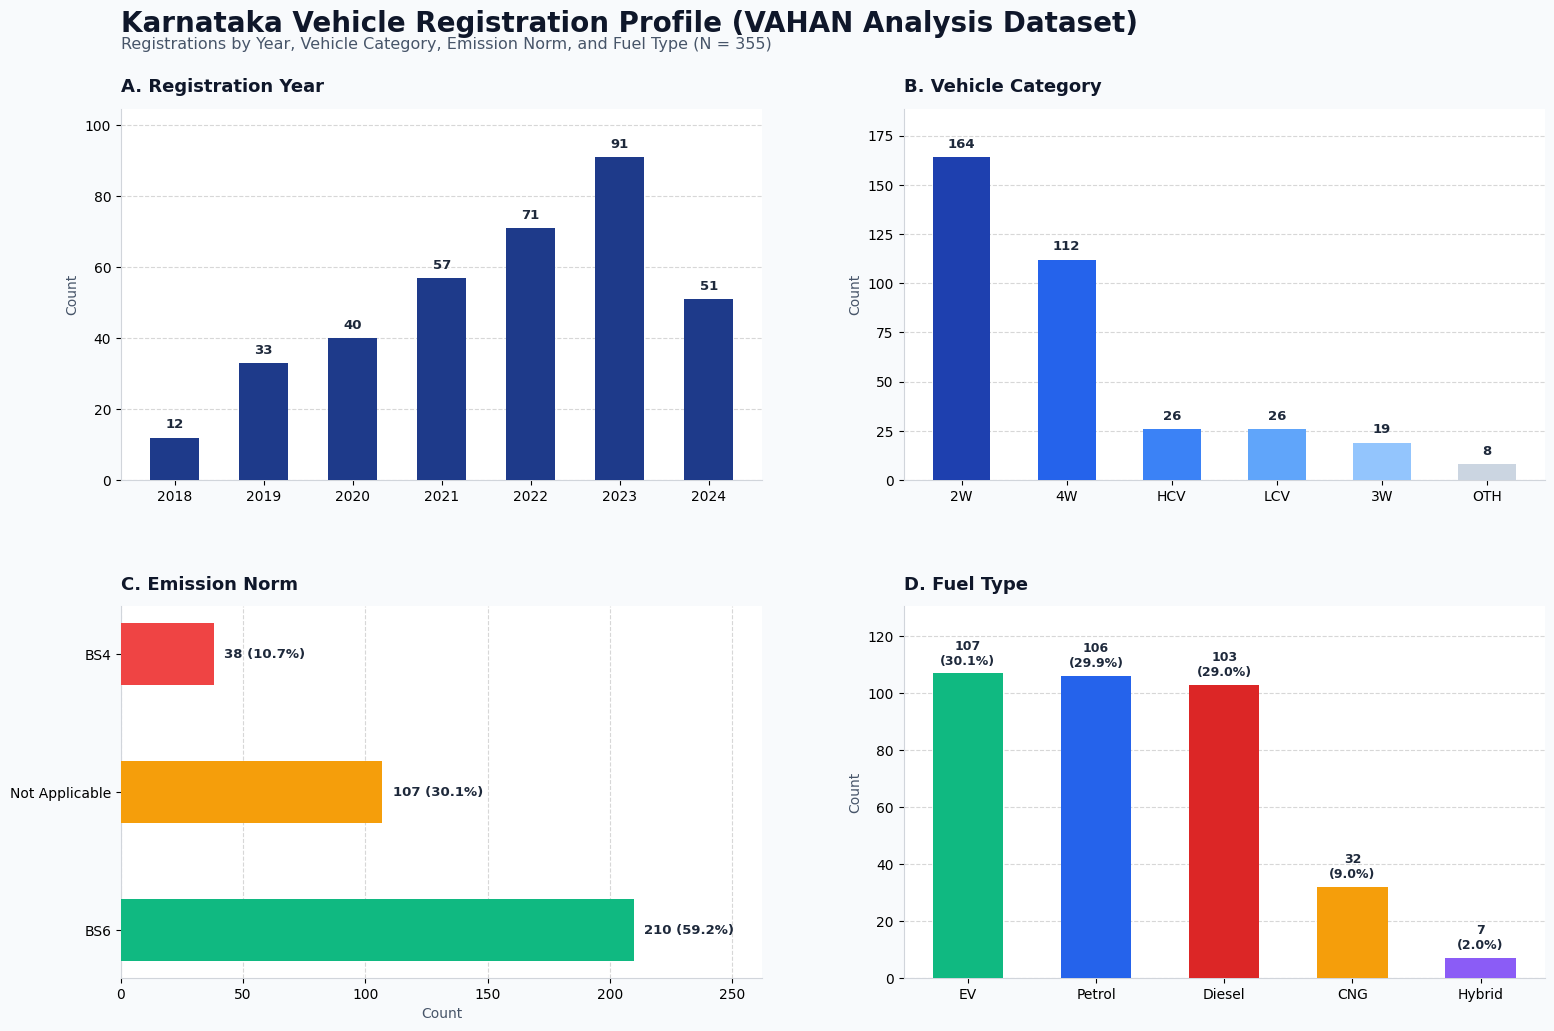

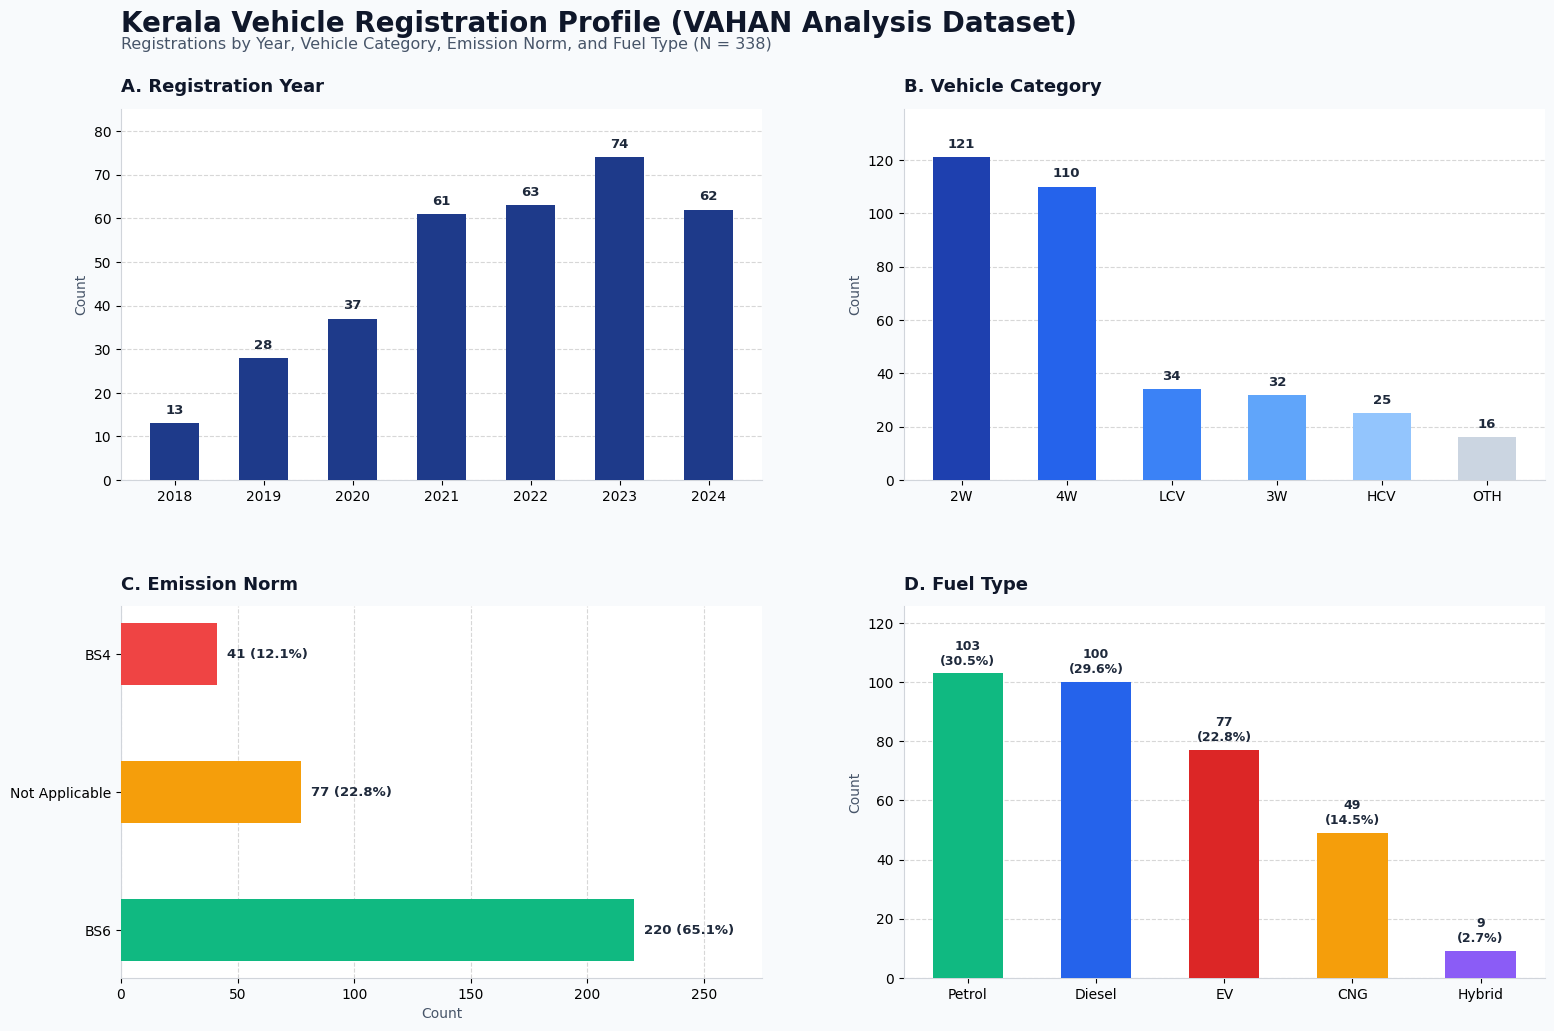

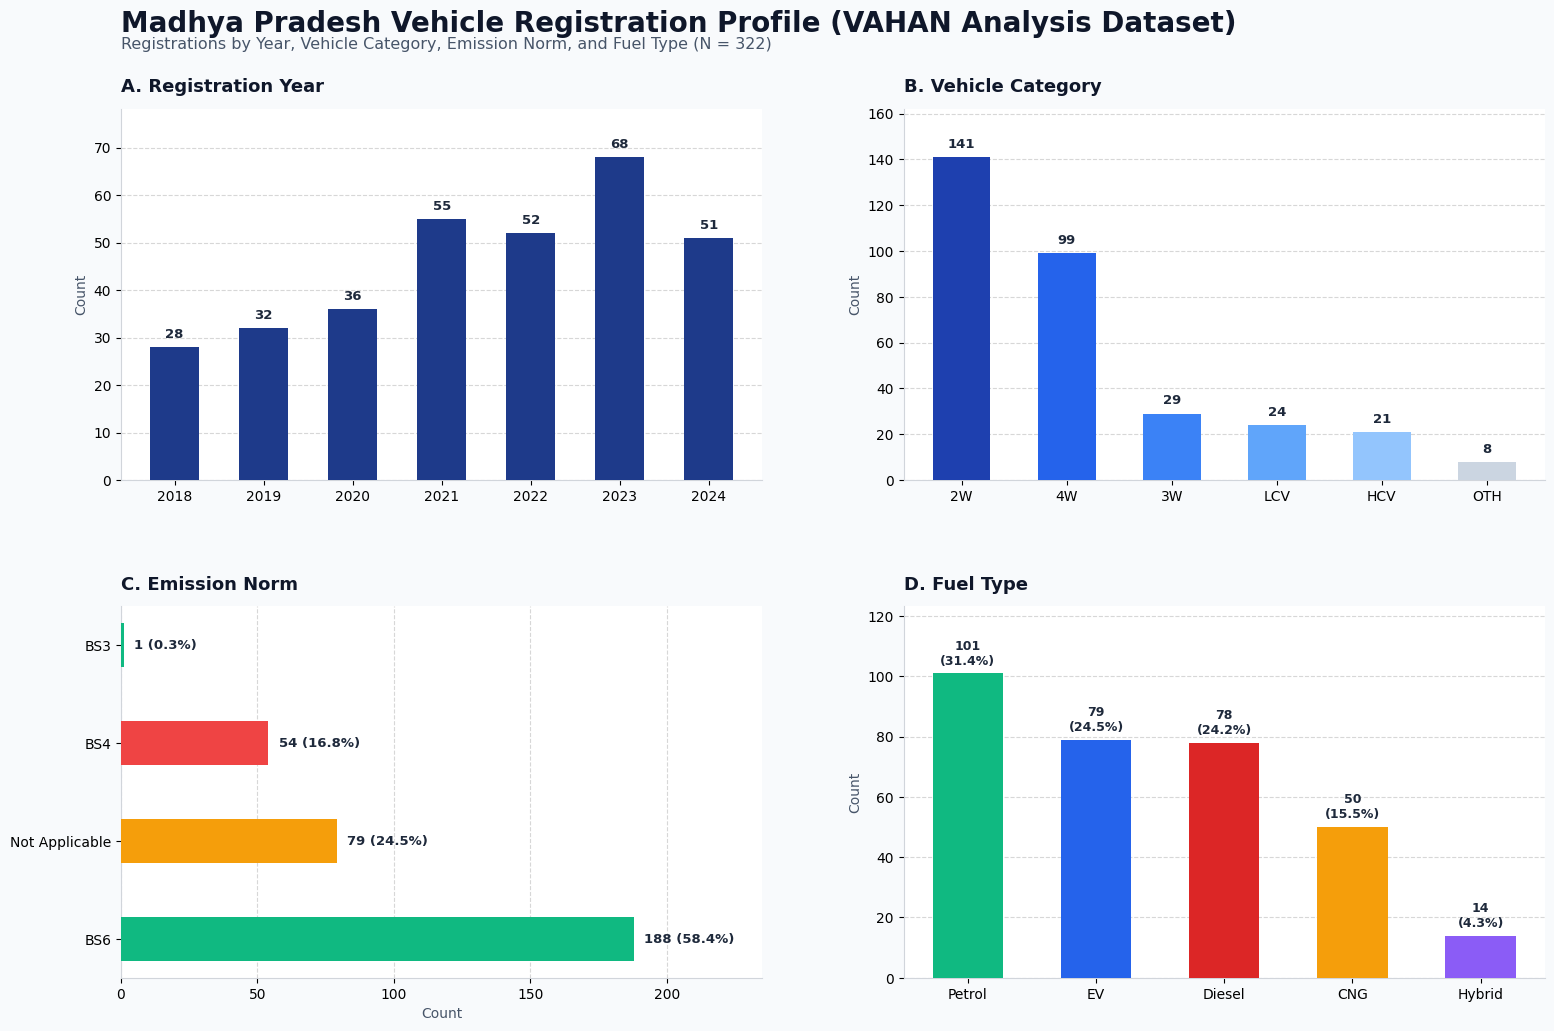

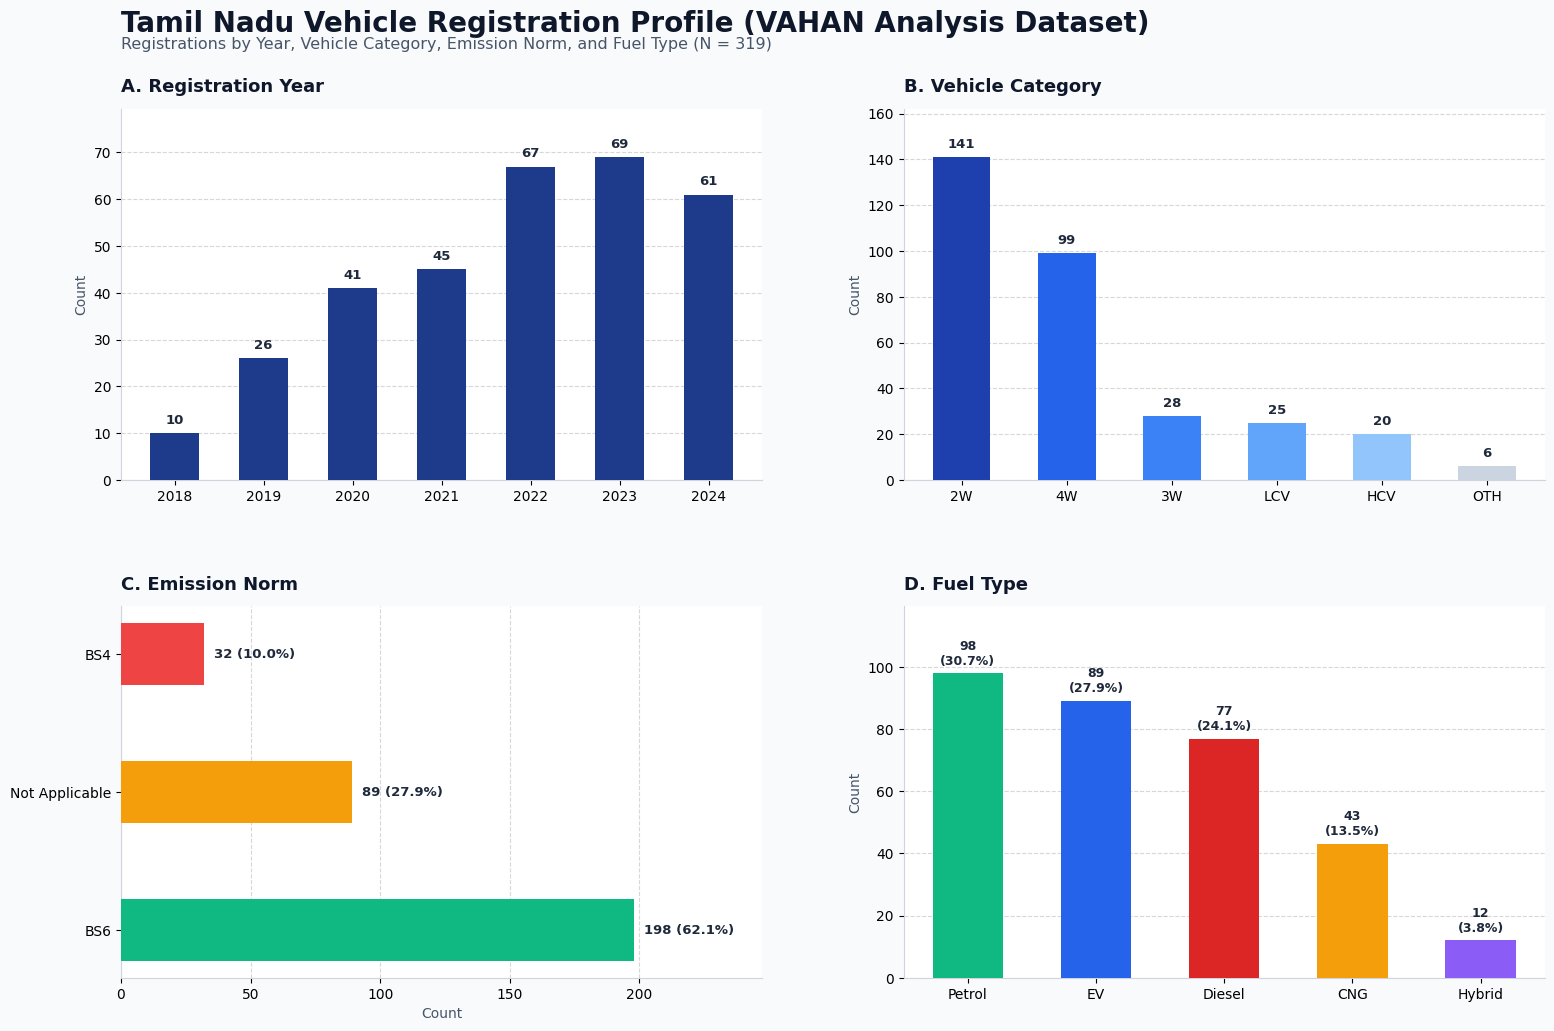

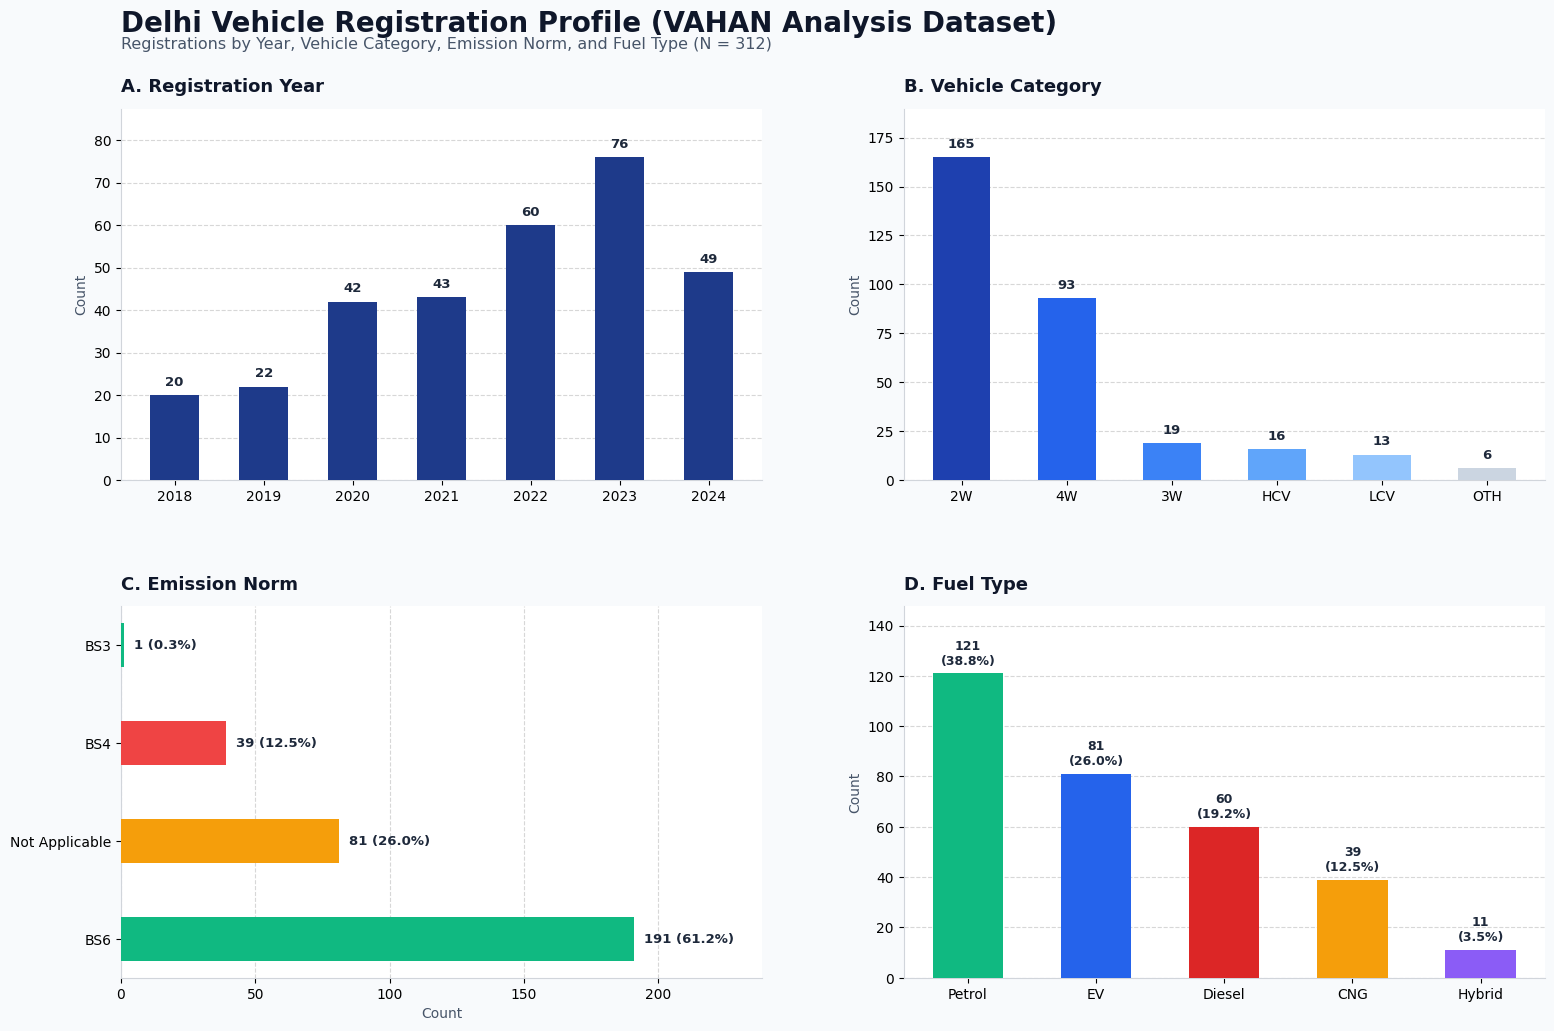

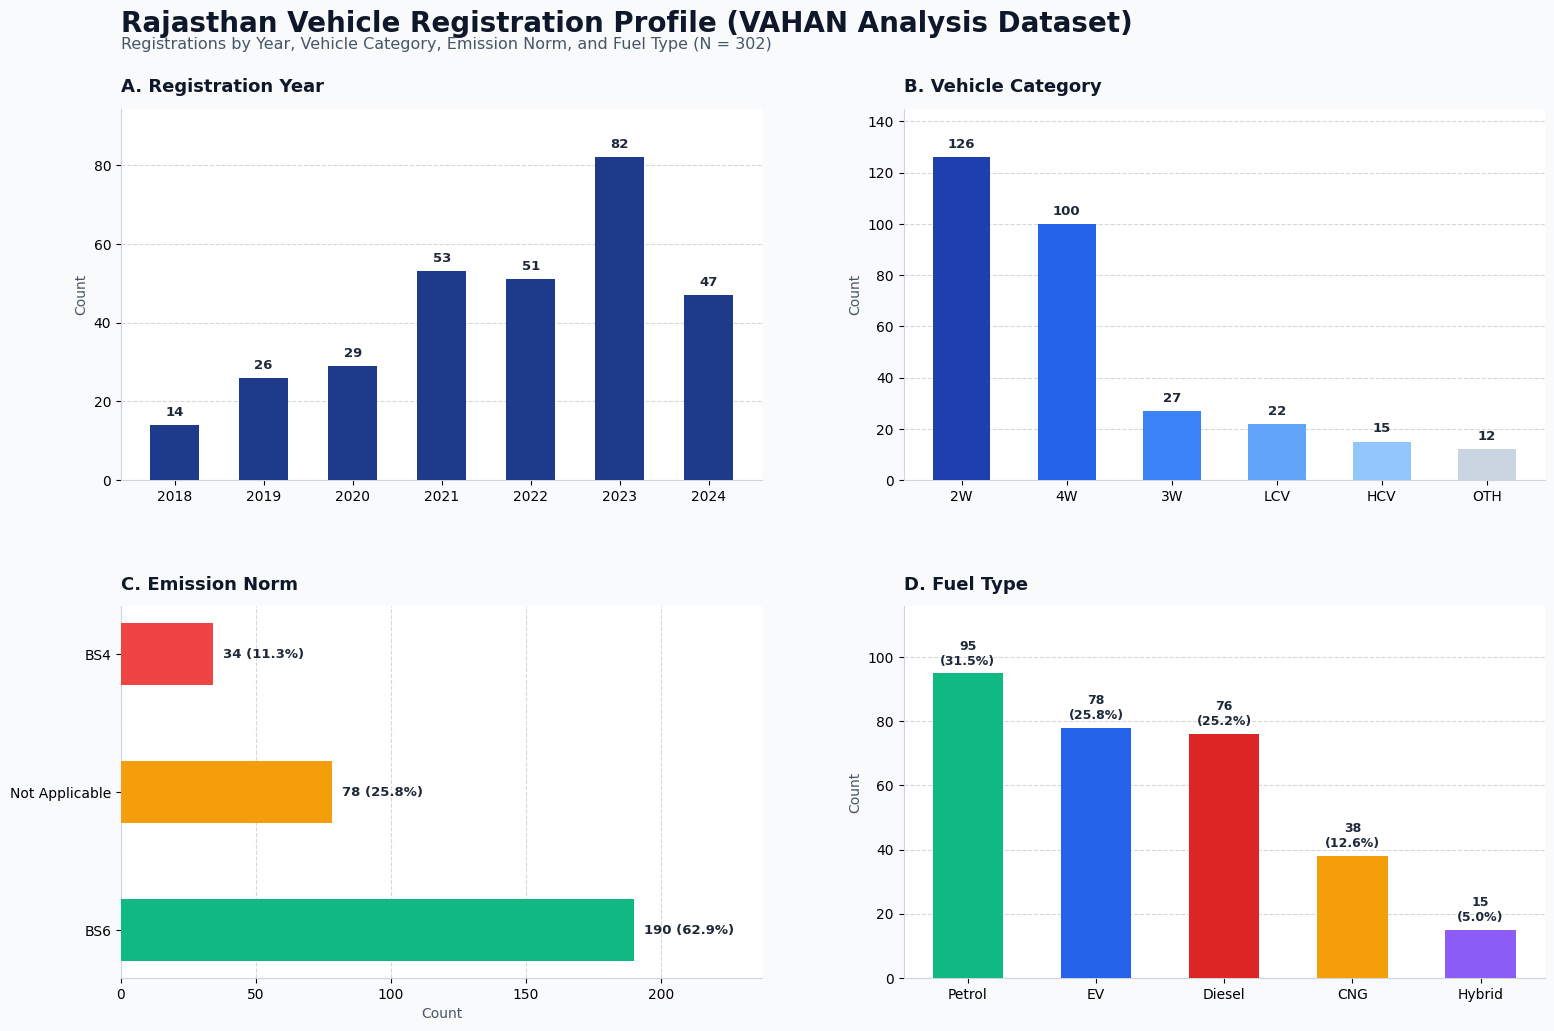

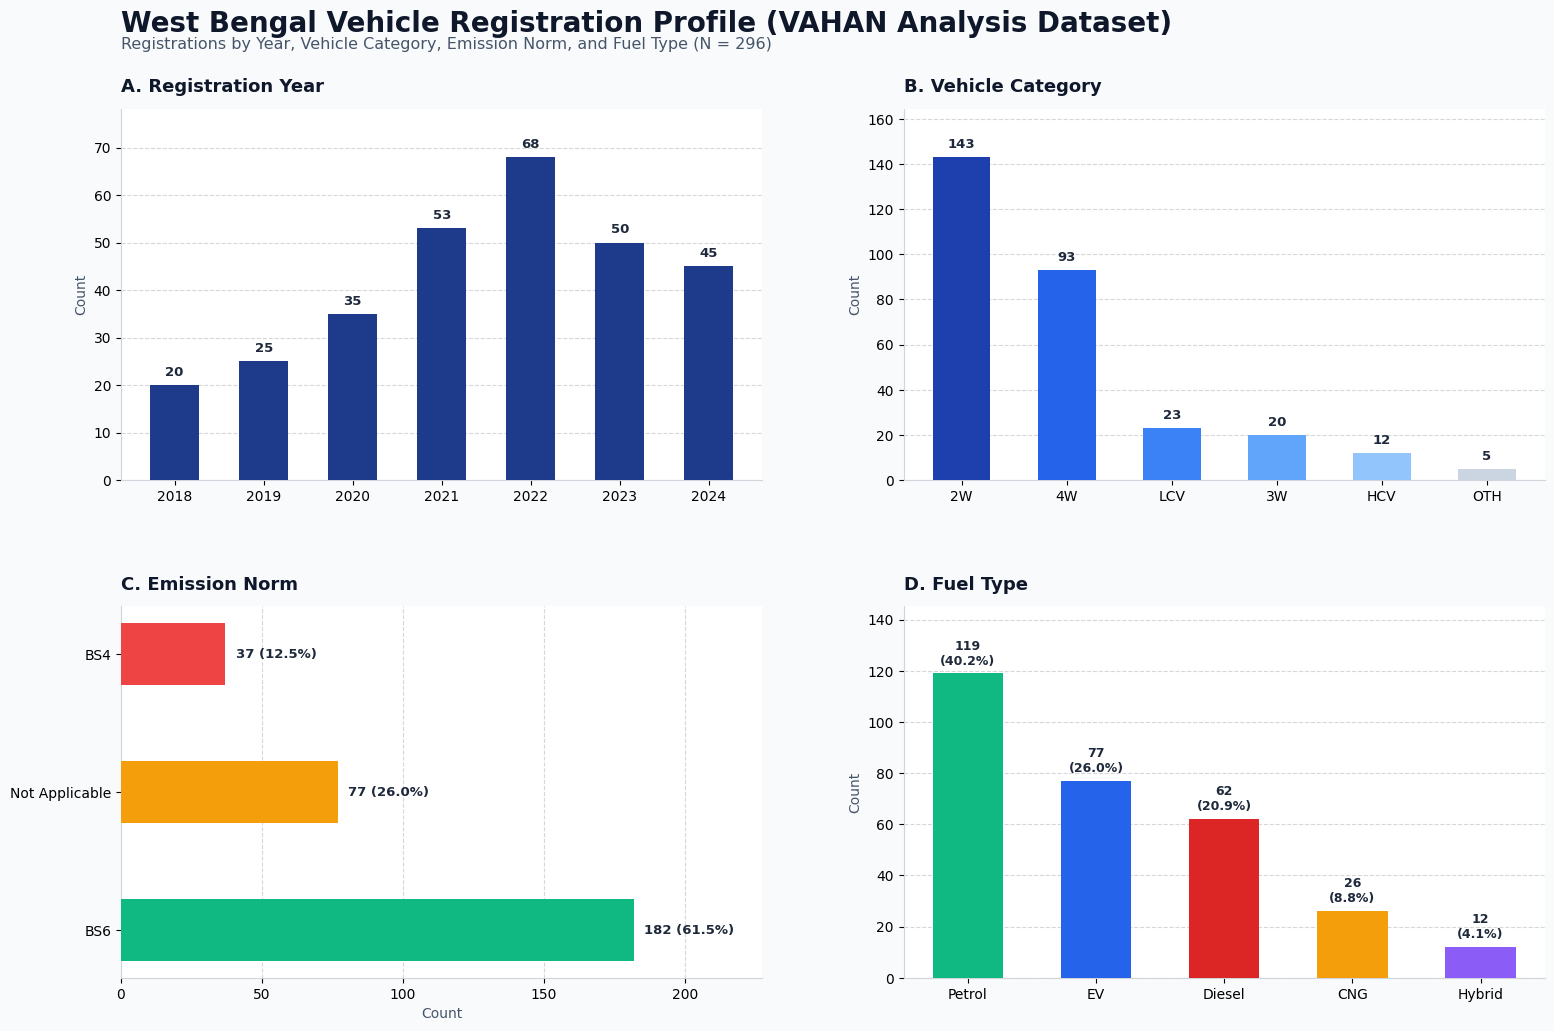

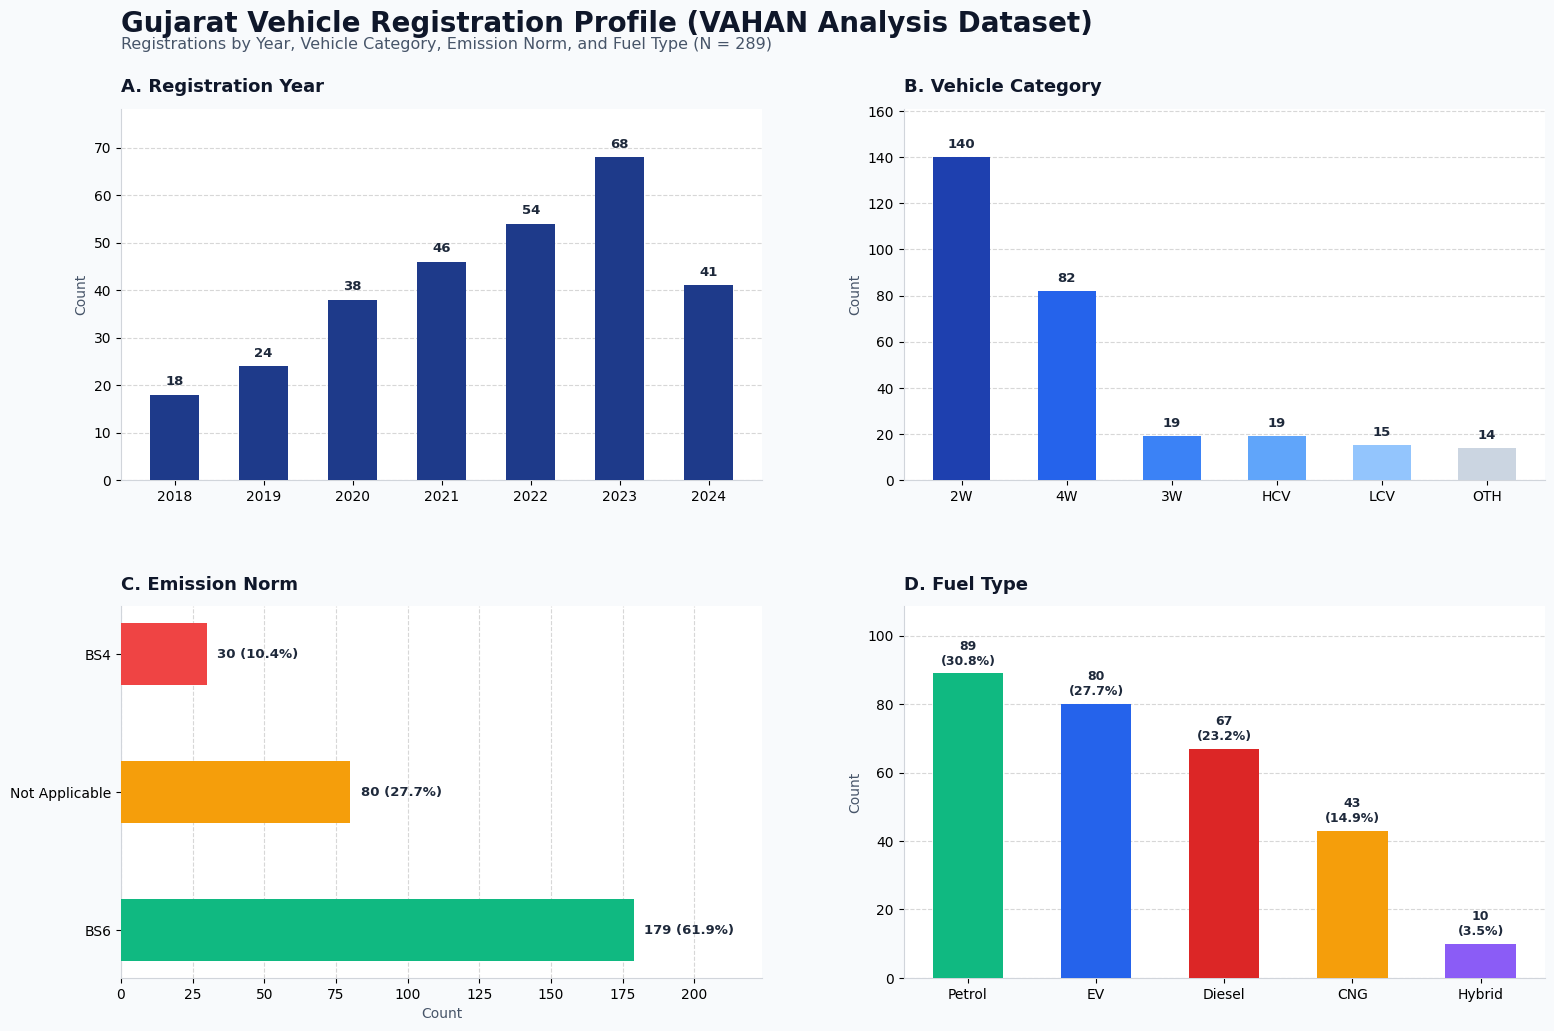

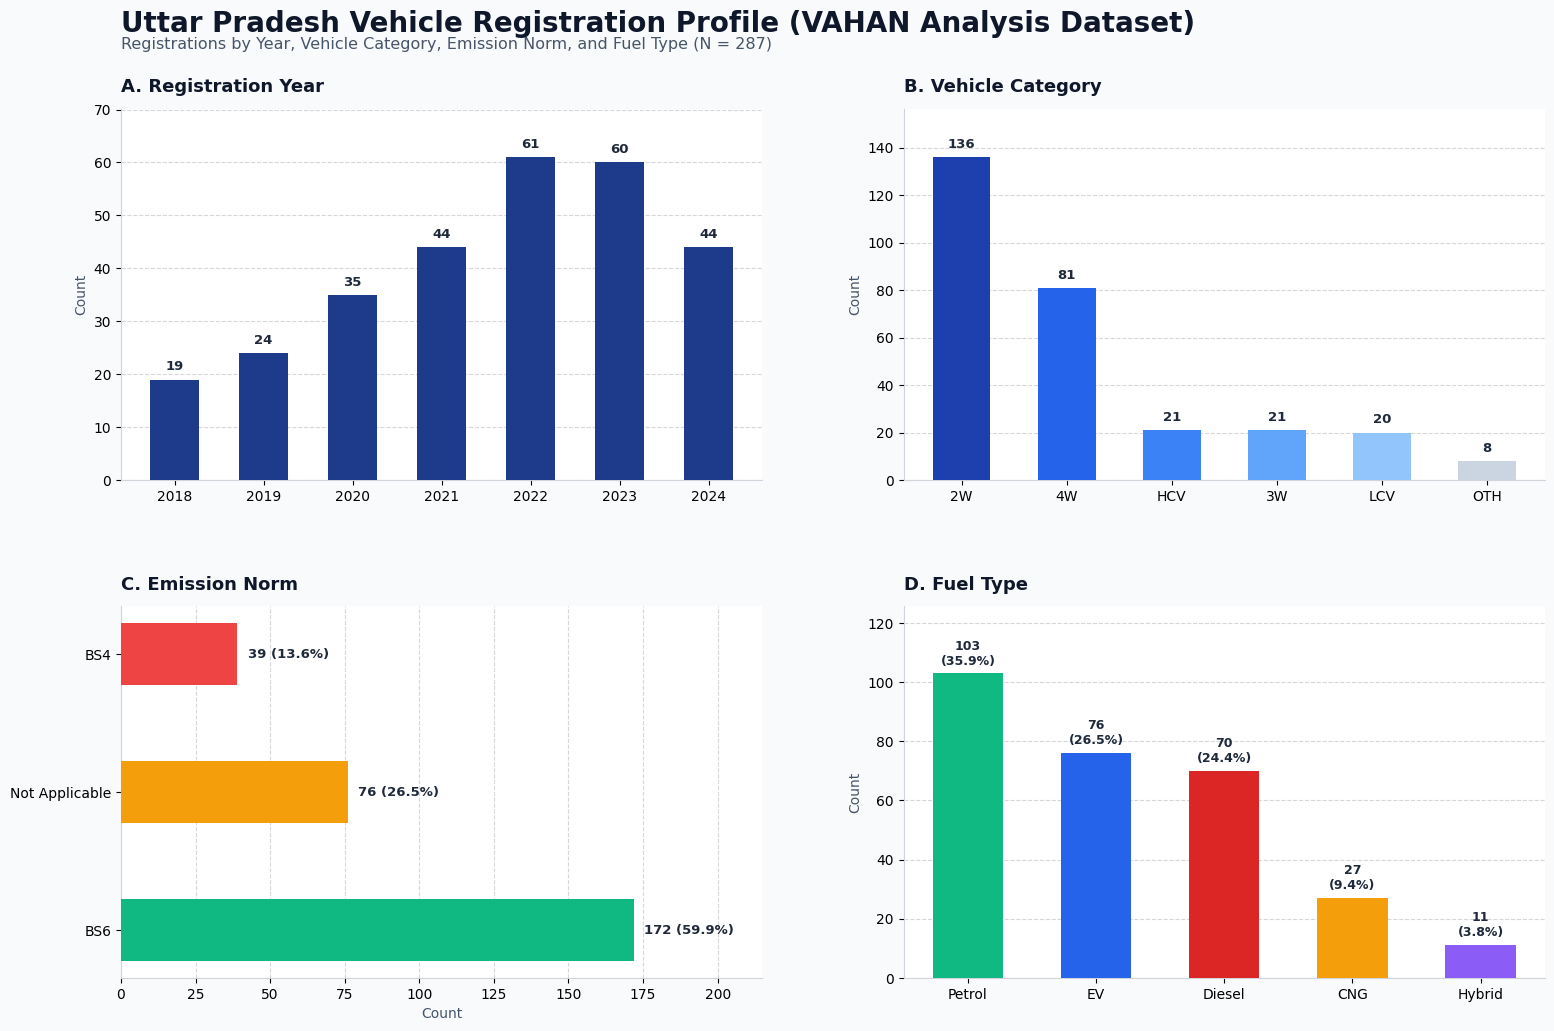

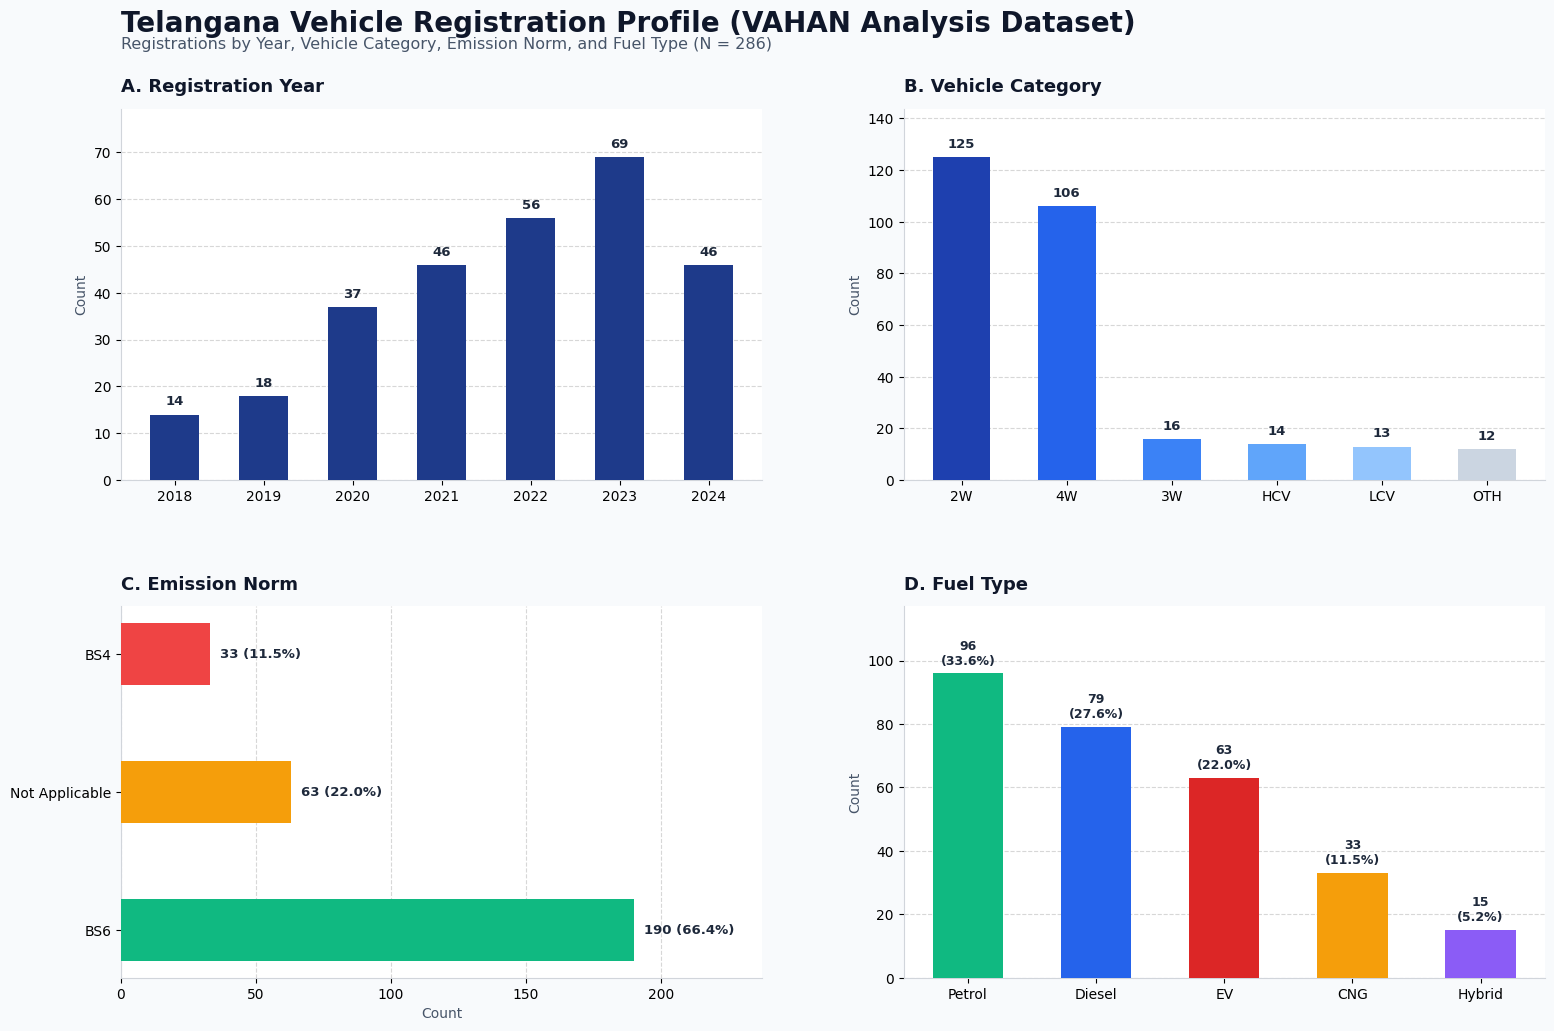

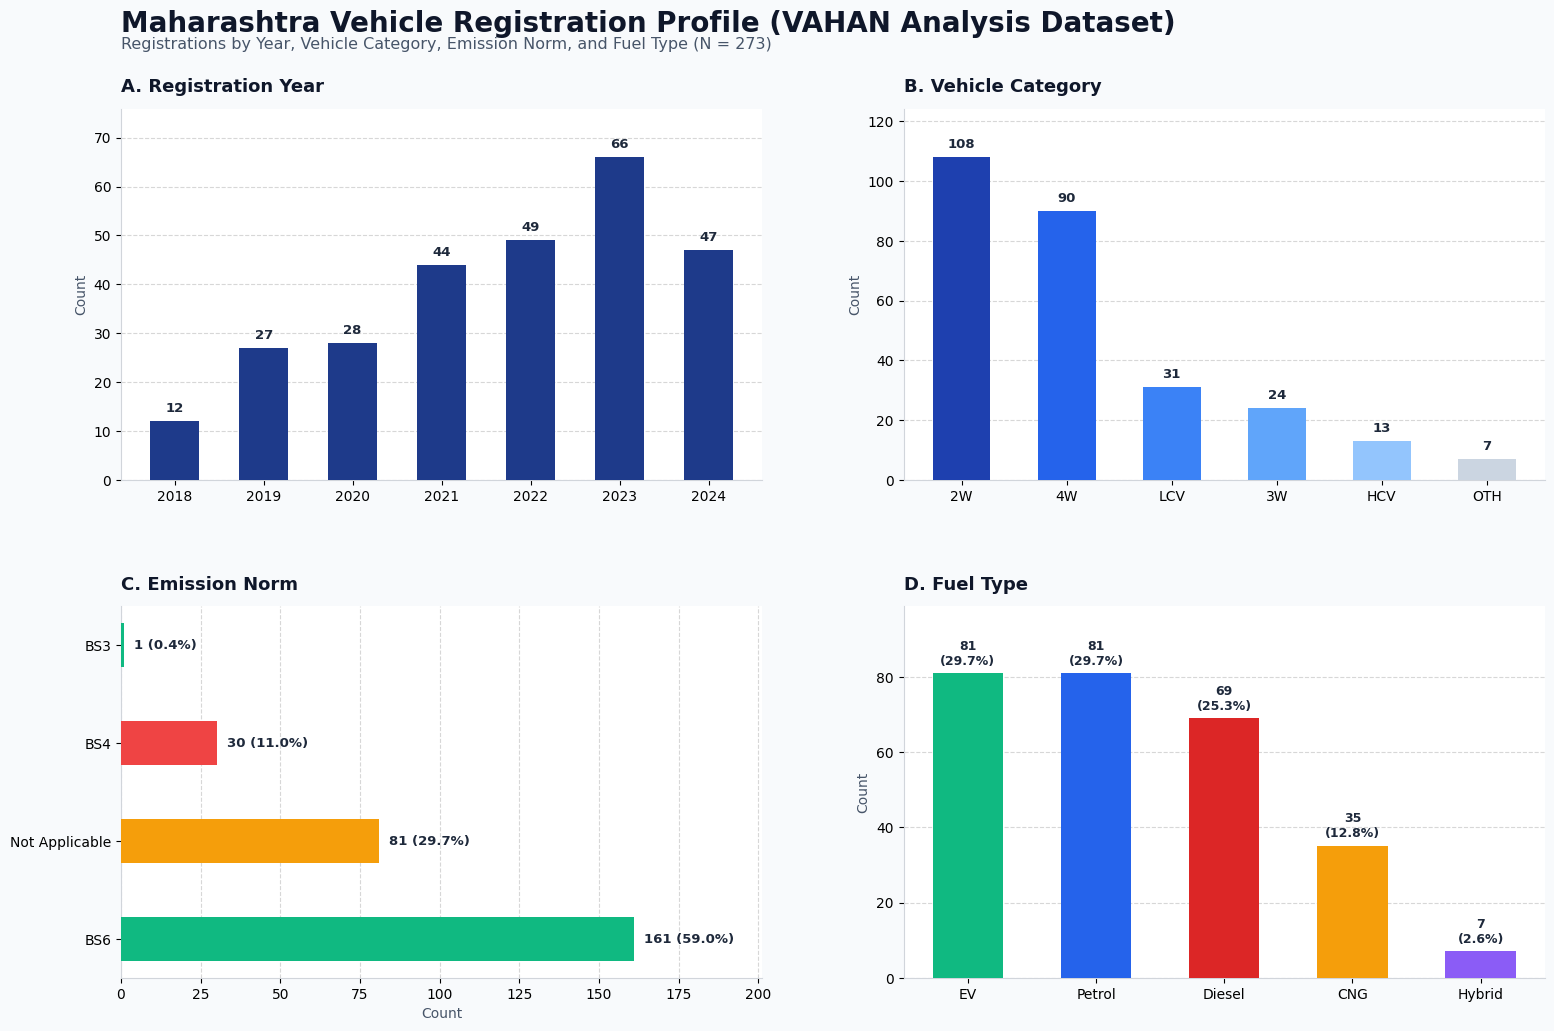

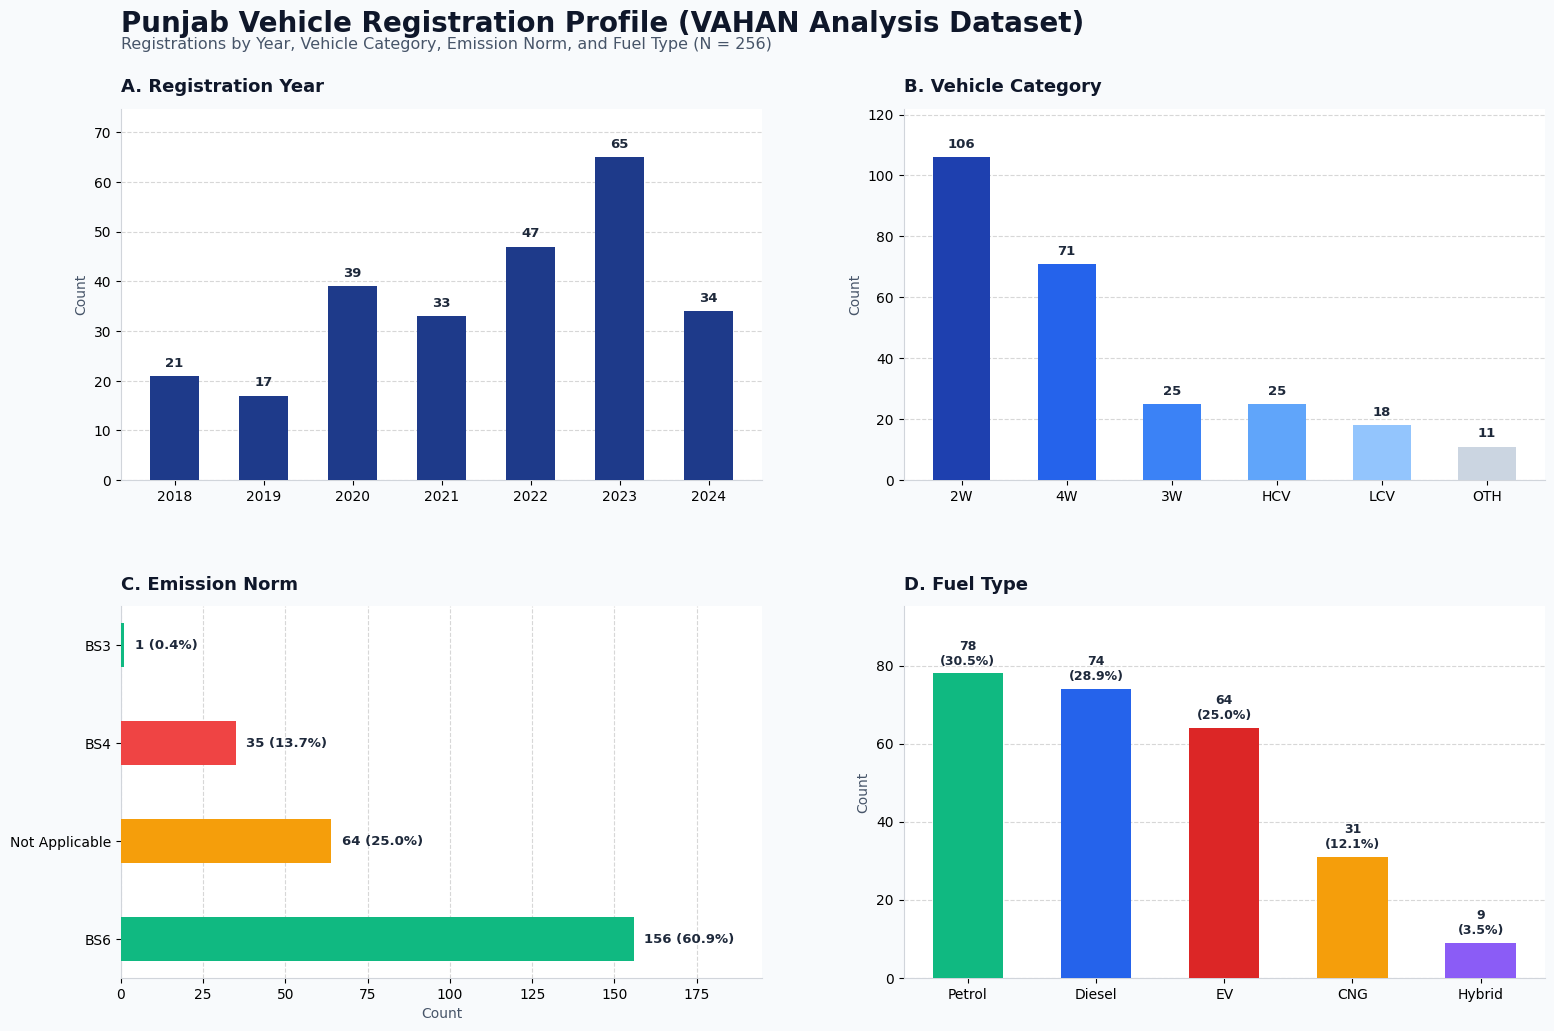

In [47]:
# Generate plots for each of the 12 states.
for s in top_12_states:
    generate_state_vahan_profile(df, s)

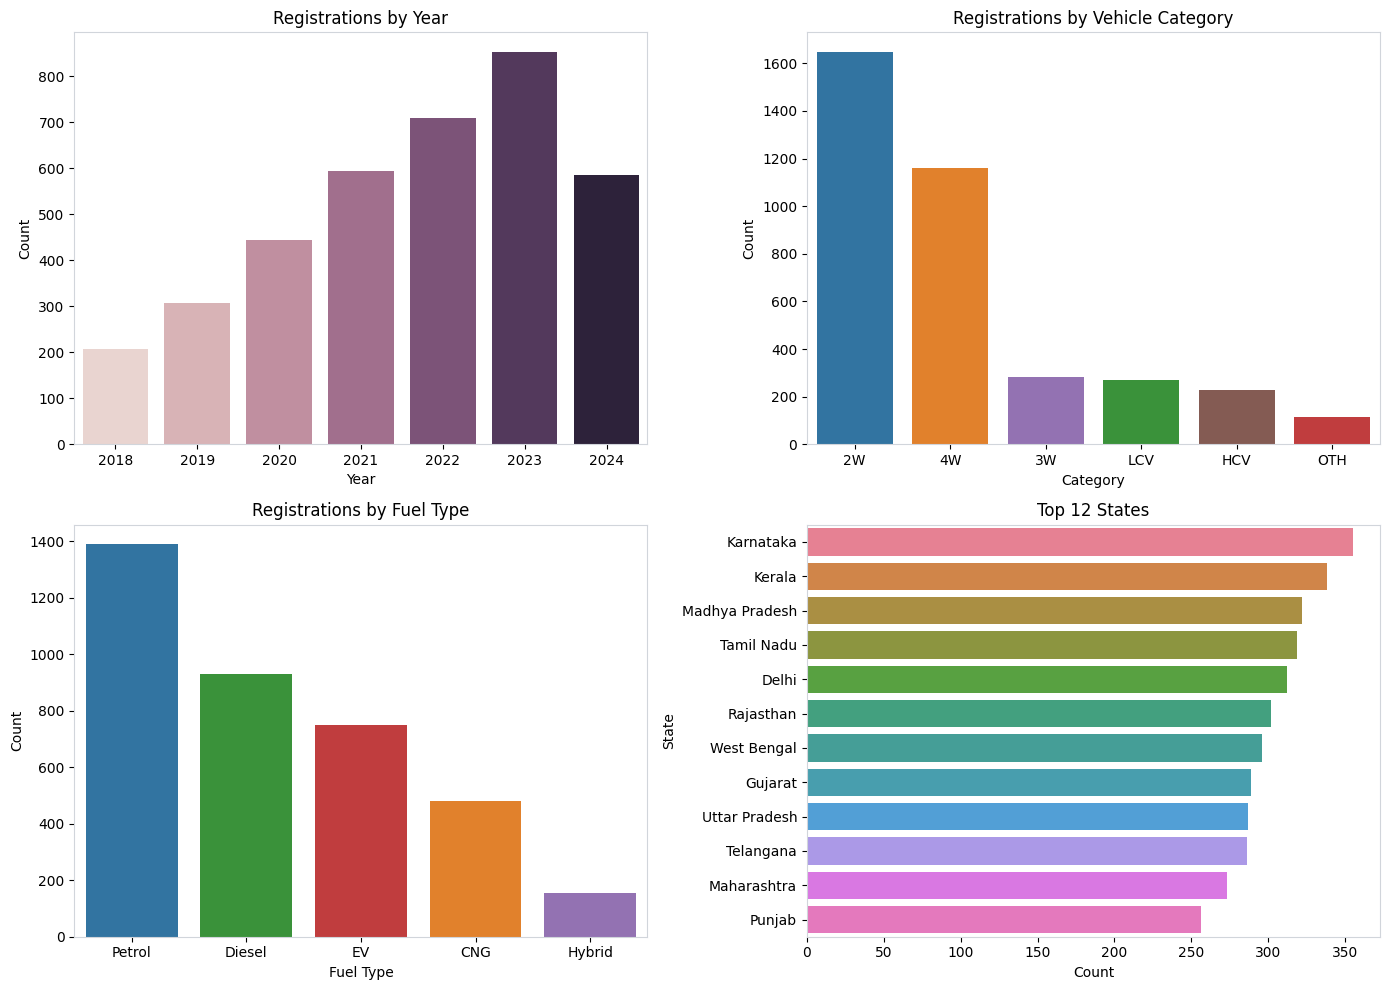

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Registrations by Year

year_counts = df['registration_year'].value_counts().sort_index()

sns.barplot(
    x=year_counts.index,
    y=year_counts.values,
    hue=year_counts.index,
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Registrations by Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Count")


# 2. Registrations by Vehicle Category

sns.countplot(
    data=df,
    x='vehicle_category',
    order=df['vehicle_category'].value_counts().index,
    hue='vehicle_category',
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Registrations by Vehicle Category")
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Count")


# 3. Registrations by Fuel Type

sns.countplot(
    data=df,
    x='fuel_type',
    order=df['fuel_type'].value_counts().index,
    hue='fuel_type',
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Registrations by Fuel Type")
axes[1, 0].set_xlabel("Fuel Type")
axes[1, 0].set_ylabel("Count")


# 4. Top 12 States

top_states = df['state_clean'].value_counts().head(12)

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index,
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Top 12 States")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("State")


plt.tight_layout()
plt.show()

In [49]:
# from sqlalchemy import create_engine
# from urllib.parse import quote_plus
# import traceback

# username = 'postgres'
# password = 'Patil@145'
# host = 'localhost'
# port = '5432'
# database = 'vehicle_registration'

# # URL-encode the password so special chars (like @) don't break the URI
# password_enc = quote_plus(password)

# engine = create_engine(
#     f"postgresql+psycopg2://{username}:{password_enc}@{host}:{port}/{database}",
#     echo=False
# )

# # Quick test + helpful error output
# try:
#     with engine.connect() as conn:
#         print("✅ Connected to PostgreSQL successfully.")
# except Exception as e:
#     print("❌ Connection failed. Full traceback below:")
#     traceback.print_exc()


In [50]:
# import psycopg2
# import traceback

# try:
#     conn = psycopg2.connect(
#         dbname="customer_behavior",
#         user="postgres",
#         password="Patil@145",
#         host="localhost",
#         port="5432"
#     )
#     print("✅ psycopg2 connected successfully")
#     conn.close()
# except Exception:
#     print("❌ psycopg2 connection failed — traceback:")
#     traceback.print_exc()

In [51]:
# df.to_sql("vehicle_details", engine, if_exists="replace", index=False)
# print("✅ Table created: vehicle_details")

In [52]:
df.head()

,registration_number,registration_date,registration_year,state,rto_office,vehicle_category,vehicle_sub_type,manufacturer_brand,fuel_type,emission_norm,engine_cc,seating_capacity,vehicle_age_years,registration_month,registration_day,registration_dayofweek,rto_state_prefix,state_clean,state_mismatch_flag,fuel_type_clean
0,REG100001,2019-12-13,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5,12,13,Friday,MP,Madhya Pradesh,0,Petrol
1,REG100002,2020-01-14,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4,1,14,Tuesday,KA,Karnataka,0,Petrol
2,REG100003,2023-03-23,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,Not Applicable,0,2,1,3,23,Thursday,DL,Delhi,1,EV
3,REG100004,2021-06-26,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3,6,26,Saturday,RJ,Rajasthan,1,Petrol
4,REG100005,2022-11-13,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2,11,13,Sunday,GJ,Gujarat,1,Petrol


In [53]:
df.to_csv("VahaanDataset_after_cleaning.csv")

In [54]:
df.head()

,registration_number,registration_date,registration_year,state,rto_office,vehicle_category,vehicle_sub_type,manufacturer_brand,fuel_type,emission_norm,engine_cc,seating_capacity,vehicle_age_years,registration_month,registration_day,registration_dayofweek,rto_state_prefix,state_clean,state_mismatch_flag,fuel_type_clean
0,REG100001,2019-12-13,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5,12,13,Friday,MP,Madhya Pradesh,0,Petrol
1,REG100002,2020-01-14,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4,1,14,Tuesday,KA,Karnataka,0,Petrol
2,REG100003,2023-03-23,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,Not Applicable,0,2,1,3,23,Thursday,DL,Delhi,1,EV
3,REG100004,2021-06-26,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3,6,26,Saturday,RJ,Rajasthan,1,Petrol
4,REG100005,2022-11-13,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2,11,13,Sunday,GJ,Gujarat,1,Petrol
